## Import Packages


In [1]:
# import all packages needed to run the code
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
import scipy.interpolate as interp

# import functions from custom libraries
import neural_network_class
import data_functions as df
import neural_network_functions as nn

Multi-task learning potential code: https://stackoverflow.com/questions/69822474/multi-task-learning-with-ann
I can't see how this will work for regression though...

## Import Data to train/test model on


In [2]:
# import datasets
names = ["1234 1", "1234 2", "1234 3", "5808 1", "5808 2", "5808 3", "5808 4", "5808 5", \
    "21313 1", "21313 2", "21313 3", "21313 4", "21313 5", "21313 6",
    "20504 1", "20504 2", "20504 3", "20504 4", "20504 5", "20504 6", "20504 7", 
    "12784 1", "12784 2", "12784 3", "12784 4", "12784 5", "12784 6", "12784 7", 
    "2625 1", "2625 2", "2625 3", "2625 4", "2625 5"]

inData = []
targetData = []
tData = []

inDataSize = np.zeros(33)
targetDataSize = np.zeros(33)
tDataSize = np.zeros(33)
i = 0

for name in names:
    [input, inputSize] = df.LoadData("Filtered Data/"+name+"_mav.csv", False)
    [target, targetSize] = df.LoadData("Filtered Data/"+name+"_ps.csv", False) # this used to be "_p.csv"
    [t, tSize] = df.LoadData("Filtered Data/"+name+"_t.csv", True) 
    
    inDataSize[i] = inputSize[0]
    targetDataSize[i] = targetSize[0]
    tDataSize[i] = tSize[0]
    i = i+1

    inData.append(input)
    targetData.append(target)
    tData.append(t)

inData = np.array(inData, dtype=object)
targetData = np.array(targetData, dtype=object)
tData = np.array(tData, dtype=object)

## Plot Output data against time


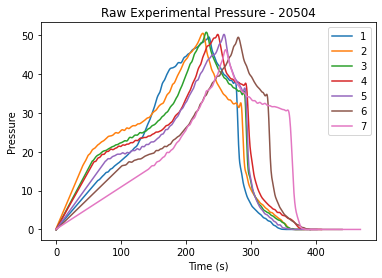

In [3]:
plt.figure()
plt.plot(tData[14], targetData[14], label='1')    
plt.plot(tData[15], targetData[15], label='2')
plt.plot(tData[16], targetData[16], label='3')
plt.plot(tData[17], targetData[17], label='4')
plt.plot(tData[18], targetData[18], label='5')
plt.plot(tData[19], targetData[19], label='6')
plt.plot(tData[20], targetData[20], label='7')
plt.ylabel('Pressure')
plt.xlabel('Time (s)')
plt.title('Raw Experimental Pressure - 20504')
plt.legend()
plt.show()

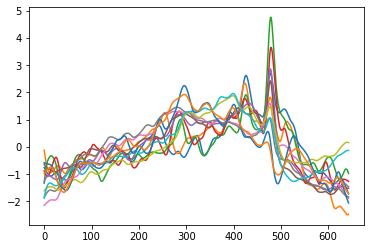

In [4]:
plt.figure()
plt.plot(inData[14])
plt.show()

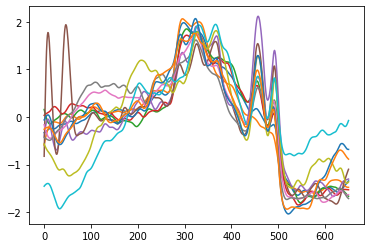

In [5]:
plt.figure()
plt.plot(inData[15])
plt.show()

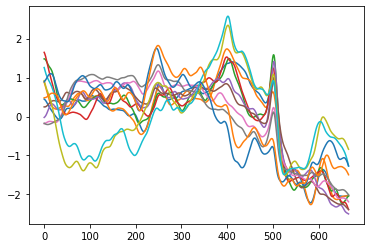

In [6]:
plt.figure()
plt.plot(inData[16])
plt.show()

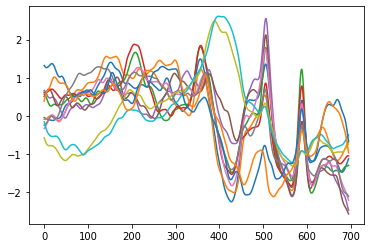

In [7]:
plt.figure()
plt.plot(inData[17])
plt.show()

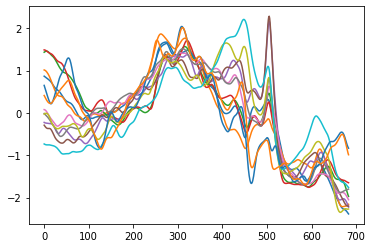

In [8]:
plt.figure()
plt.plot(inData[18])
plt.show()

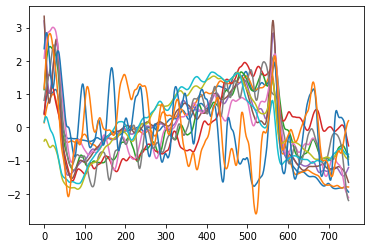

In [9]:
plt.figure()
plt.plot(inData[19])
plt.show()

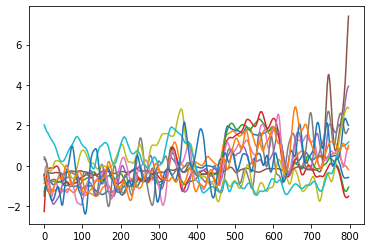

In [10]:
plt.figure()
plt.plot(inData[20])
plt.show()

## Interpolate and Normalise Data


In [11]:
processedInData = []
processedOutData = []

train_names = ["1234 1", "1234 2", "5808 1", "5808 2", "5808 3", "5808 4", "21313 1", "21313 2",\
    "21313 3", "20504 1", "20504 2", "20504 3", "20504 4", "12784 1", "12784 2", "12784 3", 
    "12784 4", "2625 1", "2625 2", "2625 3"]
test_names = ["1234 3", "5808 5", "21313 4", "20504 5", "12784 5", "2625 4"]
validation_names = ["21313 5", "21313 6", "20504 6", "20504 7", "12784 6", "12784 7", "2625 5"]

for i in range(len(names)):
    if names[i] in test_names:
        [inData[i], targetData[i]] = df.InterpData(inData[i], targetData[i], inData[i-1]) # for plotting on same axis

    [processedIn, processedOut] = df.NormaliseData(inData[i], targetData[i])
    processedInData.append(processedIn)
    processedOutData.append(processedOut)

## Create Model


In [12]:
inputTrainLSTM = []
targetTrainLSTM = []
inputTestLSTM = []
targetTestLSTM = []

# First generate the windowed data for each dataset
for i in range(len(names)):
    [inputTrain, targetTrain, inputTest, targetTest] = df.TestTrainGen_Window(processedInData[i], processedOutData[i], 12)
    inputTrainLSTM.append(inputTrain)
    targetTrainLSTM.append(targetTrain)
    inputTestLSTM.append(inputTest)
    targetTestLSTM.append(targetTest)

print("---------------------------")
print(inputTrainLSTM[0].shape, "train samples")
print(targetTrainLSTM[0].shape, "target samples")
print(inputTestLSTM[0].shape, "test input")
print(targetTestLSTM[0].shape, "test target")
print("---------------------------")

---------------------------
(330, 12, 12) train samples
(330, 1) target samples
(413, 12, 12) test input
(413, 1) test target
---------------------------


In [13]:
# Next concatenate all datasets that have been windowed that need to be tested
inputLSTM1234 = np.concatenate((inputTestLSTM[0],inputTestLSTM[1]),0)
targetLSTM1234 = np.concatenate((targetTestLSTM[0],targetTestLSTM[1]),0)

inputLSTM5808 = np.concatenate((inputTestLSTM[3],inputTestLSTM[4],inputTestLSTM[5],inputTestLSTM[6]),0)
targetLSTM5808 = np.concatenate((targetTestLSTM[3],targetTestLSTM[4],targetTestLSTM[5],targetTestLSTM[6]),0)

inputLSTM21313 = np.concatenate((inputTestLSTM[8],inputTestLSTM[9],inputTestLSTM[10]),0)
targetLSTM21313 = np.concatenate((targetTestLSTM[8],targetTestLSTM[9],targetTestLSTM[10]),0)

inputLSTM20504 = np.concatenate((inputTestLSTM[14],inputTestLSTM[15],inputTestLSTM[16],inputTestLSTM[17]),0)
targetLSTM20504 = np.concatenate((targetTestLSTM[14],targetTestLSTM[15],targetTestLSTM[16],targetTestLSTM[17]),0)

inputLSTM12784 = np.concatenate((inputTestLSTM[21],inputTestLSTM[22],inputTestLSTM[23],inputTestLSTM[24]),0)
targetLSTM12784 = np.concatenate((targetTestLSTM[21],targetTestLSTM[22],targetTestLSTM[23],targetTestLSTM[24]),0)

inputLSTM2625 = np.concatenate((inputTestLSTM[28],inputTestLSTM[29],inputTestLSTM[30]),0)
targetLSTM2625 = np.concatenate((targetTestLSTM[28],targetTestLSTM[29],targetTestLSTM[30]),0)

print("---------------")
print(inputLSTM20504.shape)
print(targetLSTM20504.shape)
print("---------------")

---------------
(2609, 12, 12)
(2609, 1)
---------------


In [14]:
# Concatenate multiple datasets
inputLSTMmulti = np.concatenate((inputLSTM1234,inputLSTM12784,inputLSTM20504),0)
targetLSTMmulti = np.concatenate((targetLSTM1234,targetLSTM12784,targetLSTM20504),0)

---------------------------
(1549, 12, 12) train samples
(1549, 1) target samples
(388, 12, 12) test input
(388, 1) test target
---------------------------
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 12, 512)           6656      
_________________________________________________________________
bidirectional (Bidirectional (None, 512)               1574912   
_________________________________________________________________
batch_normalization (BatchNo (None, 512)               2048      
_________________________________________________________________
dense_1 (Dense)              (None, 128)               65664     
_________________________________________________________________
dense_2 (Dense)              (None, 64)                8256      
_________________________________________________________________
dense_3 (Dense)              (No

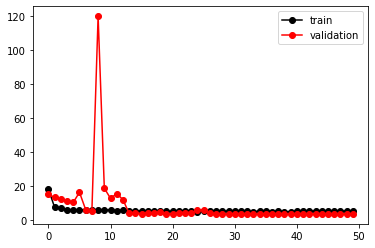

In [15]:
# Next use train test split to move data into training and testing. This will also shuffle the three datasets.
from sklearn.model_selection import train_test_split
# [inputTrainLSTM, xValLSTM, targetTrainLSTM, yValLSTM] = train_test_split(inputLSTM1234, targetLSTM1234, test_size=0.2, shuffle=True)
# [inputTrainLSTM, xValLSTM, targetTrainLSTM, yValLSTM] = train_test_split(inputLSTM5808, targetLSTM5808, test_size=0.2, shuffle=True)
# [inputTrainLSTM, xValLSTM, targetTrainLSTM, yValLSTM] = train_test_split(inputLSTM21313, targetLSTM21313, test_size=0.2, shuffle=True)
# [inputTrainLSTM, xValLSTM, targetTrainLSTM, yValLSTM] = train_test_split(inputLSTM20504, targetLSTM20504, test_size=0.6, shuffle=True)
# [inputTrainLSTM, xValLSTM, targetTrainLSTM, yValLSTM] = train_test_split(inputLSTM12784, targetLSTM12784, test_size=0.2, shuffle=True)
[inputTrainLSTM, xValLSTM, targetTrainLSTM, yValLSTM] = train_test_split(inputLSTM2625, targetLSTM2625, test_size=0.2, shuffle=True)

# [inputTrainLSTM, xValLSTM, targetTrainLSTM, yValLSTM] = train_test_split(inputLSTMmulti, targetLSTMmulti, test_size=0.2, shuffle=True)


print("---------------------------")
print(inputTrainLSTM.shape, "train samples")
print(targetTrainLSTM.shape, "target samples")
print(xValLSTM.shape, "test input")
print(yValLSTM.shape, "test target")
print("---------------------------")

# define the type of neural network model that will be created
ntype = "LSTM_PCA"

# CNN and TDNNs require an additional dimension
if ntype == "CNN": # or ntype == "TDNN":
    inputTrainLSTM = np.expand_dims(inputTrainLSTM, -1)
    inputTestLSTM = np.expand_dims(inputTestLSTM, -1)

# define the input shape for the neural network and initialise the class
inSize = inputLSTM20504.shape
nncLSTM = neural_network_class.NeuralNetwork(inSize, ntype)

# Train the model
nncLSTM.TrainNN(inputTrainLSTM, targetTrainLSTM, xValLSTM, yValLSTM, batch_size = 16, epochs = 50) #16


## Test Model


### Plots


22/22 [==============================] - 2s 76ms/step - loss: 9.3029 - mean_squared_error: 171.1140
Test loss: 9.30290699005127
Test accuracy: 171.11399841308594


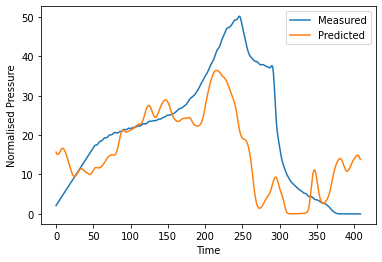

22/22 [==============================] - 2s 74ms/step - loss: 9.6617 - mean_squared_error: 147.3995
Test loss: 9.661656379699707
Test accuracy: 147.3994903564453


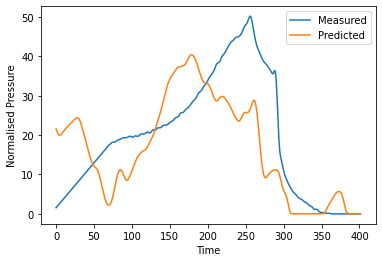

684 684 684 684


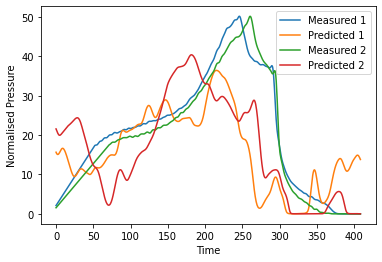

In [16]:
# now test this against the new data
[ScoreLSTM, predictionsLSTM] = nncLSTM.TestNN(inputTestLSTM[17], targetTestLSTM[17])
print("Test loss:", ScoreLSTM[0])
print("Test accuracy:", ScoreLSTM[1])
nn.PlotRegression(predictionsLSTM.flatten(), targetTestLSTM[17].flatten(), tData[17], sort=False)

[newScoreLSTM, newPredictionsLSTM] = nncLSTM.TestNN(inputTestLSTM[18], targetTestLSTM[18])
print("Test loss:", newScoreLSTM[0])
print("Test accuracy:", newScoreLSTM[1])
nn.PlotRegression(newPredictionsLSTM.flatten(), targetTestLSTM[18].flatten(), tData[18], sort=False)

nn.PlotRegression2(predictionsLSTM.flatten(), targetTestLSTM[17].flatten(), tData[17], newPredictionsLSTM.flatten(), targetTestLSTM[18].flatten())

22/22 [==============================] - 2s 77ms/step - loss: 11.5386 - mean_squared_error: 251.7079
Test loss: 11.53862476348877
Test accuracy: 251.70791625976562


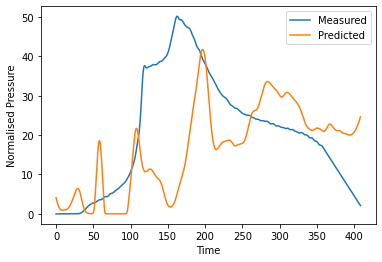

22/22 [==============================] - 2s 75ms/step - loss: 9.3029 - mean_squared_error: 171.1140
Test loss: 9.30290699005127
Test accuracy: 171.11399841308594


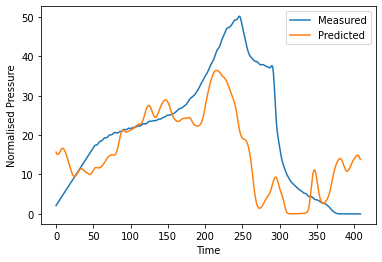

In [17]:
# now test this to see if it sill works if you flip the data 
[scoreLSTMflip, predictionsLSTMflip] = nncLSTM.TestNN(np.flip(inputTestLSTM[17]), np.flip(targetTestLSTM[17]))
print("Test loss:", scoreLSTMflip[0])
print("Test accuracy:", scoreLSTMflip[1])
nn.PlotRegression(predictionsLSTMflip.flatten(), np.flip(targetTestLSTM[17].flatten()), tData[17], sort=False)

# now test this against the right cut data
[scoreLSTMflip, predictionsLSTMflip] = nncLSTM.TestNN((inputTestLSTM[17]), (targetTestLSTM[17]))
print("Test loss:", scoreLSTMflip[0])
print("Test accuracy:", scoreLSTMflip[1])
nn.PlotRegression(predictionsLSTM.flatten(), targetTestLSTM[17].flatten(), tData[17], sort=False)

--------------------------------
Predicting Bladder Pressure for dataset 1234 1
13/13 [==============================] - 1s 83ms/step - loss: 13.1705 - mean_squared_error: 297.8360
Test loss: 13.170543670654297
Test accuracy: 297.83599853515625
Final score (MSE): 297.8359960576475
Final score (RMSE): 17.25792560123167
Final score (RMSPE): 4917.655589738208%
--------------------------------


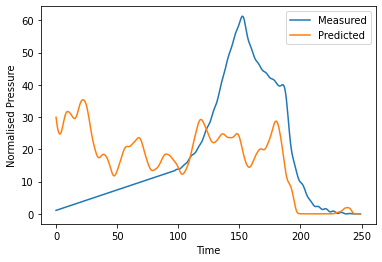

--------------------------------
Predicting Bladder Pressure for dataset 1234 2
12/12 [==============================] - 1s 75ms/step - loss: 13.6906 - mean_squared_error: 268.5204
Test loss: 13.690613746643066
Test accuracy: 268.52044677734375
Final score (MSE): 268.52046335103006
Final score (RMSE): 16.386594013126402
Final score (RMSPE): 196.12746073797547%
--------------------------------


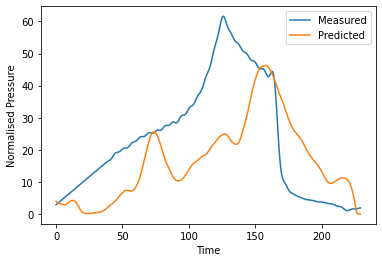

--------------------------------
Predicting Bladder Pressure for dataset 1234 3
12/12 [==============================] - 1s 93ms/step - loss: 16.8576 - mean_squared_error: 510.7359
Test loss: 16.85757064819336
Test accuracy: 510.73590087890625
Final score (MSE): 510.73592078165365
Final score (RMSE): 22.599467267651548
Final score (RMSPE): 123.93691796867867%
--------------------------------


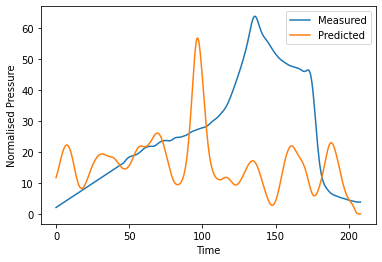

--------------------------------
Predicting Bladder Pressure for dataset 5808 1
10/10 [==============================] - 1s 88ms/step - loss: 10.6596 - mean_squared_error: 145.3296
Test loss: 10.659635543823242
Test accuracy: 145.32958984375
Final score (MSE): 145.32959536116317
Final score (RMSE): 12.055272512936536
Final score (RMSPE): 9867.911456666745%
--------------------------------


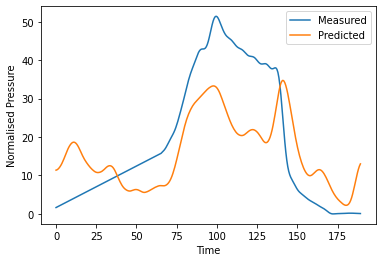

--------------------------------
Predicting Bladder Pressure for dataset 5808 2
11/11 [==============================] - 1s 85ms/step - loss: 17.0858 - mean_squared_error: 434.2900
Test loss: 17.08584976196289
Test accuracy: 434.28997802734375
Final score (MSE): 434.2899436246704
Final score (RMSE): 20.83962436380921
Final score (RMSPE): 546.0297982901335%
--------------------------------


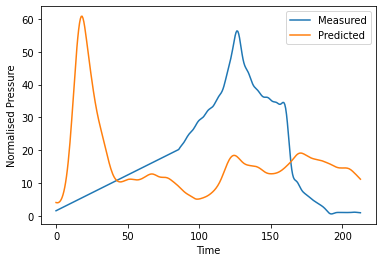

--------------------------------
Predicting Bladder Pressure for dataset 5808 3
10/10 [==============================] - 1s 92ms/step - loss: 11.7943 - mean_squared_error: 184.4509
Test loss: 11.794275283813477
Test accuracy: 184.45089721679688
Final score (MSE): 184.45089051298788
Final score (RMSE): 13.58126984169698
Final score (RMSPE): 221.99264392698112%
--------------------------------


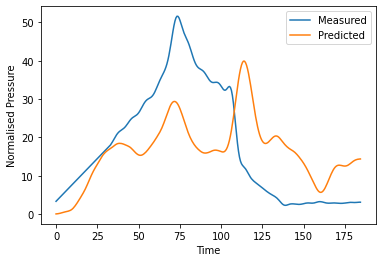

--------------------------------
Predicting Bladder Pressure for dataset 5808 4
9/9 [==============================] - 1s 85ms/step - loss: 11.1418 - mean_squared_error: 175.8230
Test loss: 11.141817092895508
Test accuracy: 175.82296752929688
Final score (MSE): 175.82296393751508
Final score (RMSE): 13.259825185028461
Final score (RMSPE): 6663.554249778126%
--------------------------------


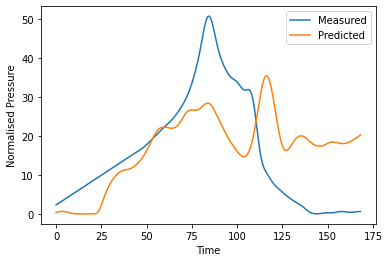

--------------------------------
Predicting Bladder Pressure for dataset 5808 5
9/9 [==============================] - 1s 83ms/step - loss: 13.6429 - mean_squared_error: 297.6906
Test loss: 13.642868041992188
Test accuracy: 297.6906433105469
Final score (MSE): 297.6906621781395
Final score (RMSE): 17.253714445827008
Final score (RMSPE): 321.9273963169232%
--------------------------------


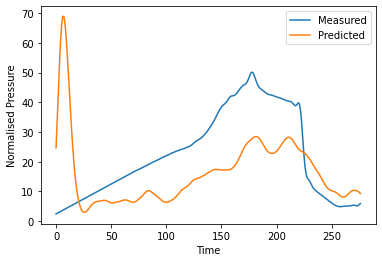

--------------------------------
Predicting Bladder Pressure for dataset 21313 1
23/23 [==============================] - 2s 81ms/step - loss: 14.4018 - mean_squared_error: 327.9908
Test loss: 14.401784896850586
Test accuracy: 327.9908447265625
Final score (MSE): 327.99083643544026
Final score (RMSE): 18.11051728790319
Final score (RMSPE): 25206.454266611574%
--------------------------------


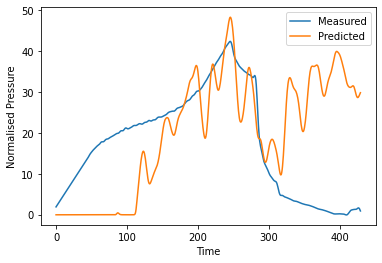

--------------------------------
Predicting Bladder Pressure for dataset 21313 2
25/25 [==============================] - 2s 88ms/step - loss: 21.2676 - mean_squared_error: 652.5629
Test loss: 21.267555236816406
Test accuracy: 652.5628662109375
Final score (MSE): 652.5628687383246
Final score (RMSE): 25.545310112392933
Final score (RMSPE): 342.7872976089919%
--------------------------------


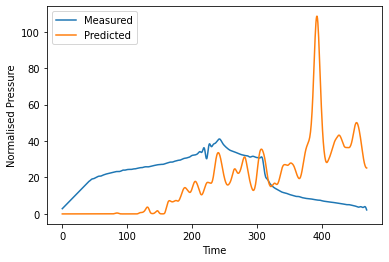

--------------------------------
Predicting Bladder Pressure for dataset 21313 3
25/25 [==============================] - 2s 88ms/step - loss: 15.2792 - mean_squared_error: 314.1552
Test loss: 15.279197692871094
Test accuracy: 314.1552429199219
Final score (MSE): 314.155231237883
Final score (RMSE): 17.724424708234764
Final score (RMSPE): 3308243.4021209558%
--------------------------------


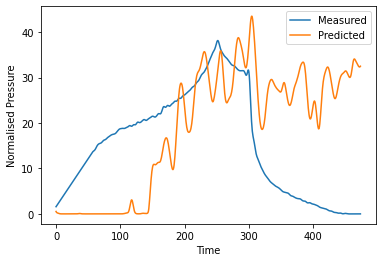

--------------------------------
Predicting Bladder Pressure for dataset 21313 4
25/25 [==============================] - 2s 94ms/step - loss: 23.0315 - mean_squared_error: 685.2983
Test loss: 23.031455993652344
Test accuracy: 685.2982788085938
Final score (MSE): 685.2983248296839
Final score (RMSE): 26.17820323913931
Final score (RMSPE): 1079.6065746153508%
--------------------------------


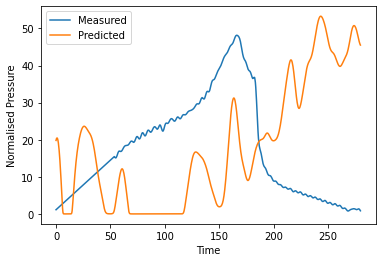

--------------------------------
Predicting Bladder Pressure for dataset 21313 5
26/26 [==============================] - 2s 85ms/step - loss: 11.3218 - mean_squared_error: 186.4341
Test loss: 11.32176399230957
Test accuracy: 186.43408203125
Final score (MSE): 186.43410085690263
Final score (RMSE): 13.654087331524675
Final score (RMSPE): 817.104902516021%
--------------------------------


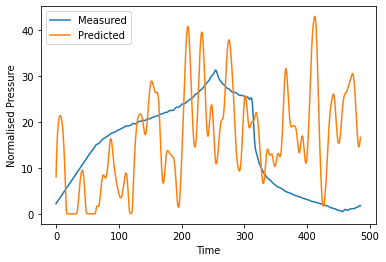

--------------------------------
Predicting Bladder Pressure for dataset 21313 6
25/25 [==============================] - 2s 91ms/step - loss: 10.2597 - mean_squared_error: 169.4255
Test loss: 10.259657859802246
Test accuracy: 169.425537109375
Final score (MSE): 169.4255472673148
Final score (RMSE): 13.016356912259083
Final score (RMSPE): 335.1847238406701%
--------------------------------


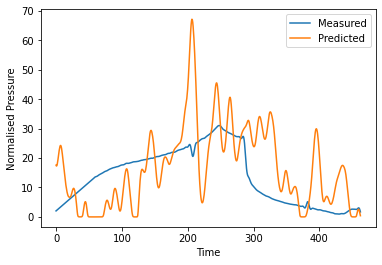

--------------------------------
Predicting Bladder Pressure for dataset 20504 1
20/20 [==============================] - 2s 82ms/step - loss: 9.0198 - mean_squared_error: 92.3055
Test loss: 9.019818305969238
Test accuracy: 92.30552673339844
Final score (MSE): 92.305529737184
Final score (RMSE): 9.607576683908592
Final score (RMSPE): 725052.5341748935%
--------------------------------


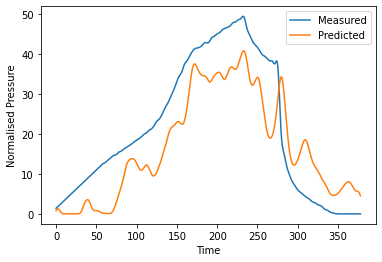

--------------------------------
Predicting Bladder Pressure for dataset 20504 2
20/20 [==============================] - 2s 95ms/step - loss: 8.0886 - mean_squared_error: 87.7981
Test loss: 8.088605880737305
Test accuracy: 87.79808807373047
Final score (MSE): 87.7980836705015
Final score (RMSE): 9.370063162567343
Final score (RMSPE): 126969.20275975672%
--------------------------------


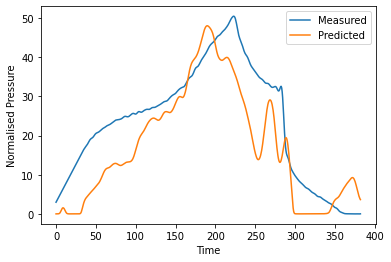

--------------------------------
Predicting Bladder Pressure for dataset 20504 3
21/21 [==============================] - 2s 84ms/step - loss: 9.2448 - mean_squared_error: 116.2542
Test loss: 9.244773864746094
Test accuracy: 116.25422668457031
Final score (MSE): 116.25423363072603
Final score (RMSE): 10.782125654560238
Final score (RMSPE): 64561.90044518141%
--------------------------------


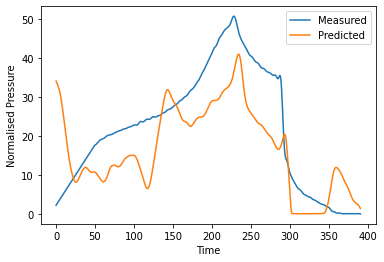

--------------------------------
Predicting Bladder Pressure for dataset 20504 4
22/22 [==============================] - 2s 88ms/step - loss: 9.3029 - mean_squared_error: 171.1140
Test loss: 9.30290699005127
Test accuracy: 171.11399841308594
Final score (MSE): 171.11400697517772
Final score (RMSE): 13.08105526993819
Final score (RMSPE): 6137064.572312081%
--------------------------------


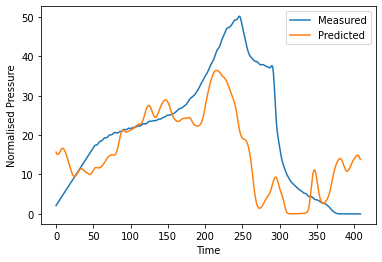

--------------------------------
Predicting Bladder Pressure for dataset 20504 5
22/22 [==============================] - 2s 91ms/step - loss: 9.6617 - mean_squared_error: 147.3995
Test loss: 9.661656379699707
Test accuracy: 147.3994903564453
Final score (MSE): 147.39948469845143
Final score (RMSE): 12.14081894677832
Final score (RMSPE): 190956.82024514282%
--------------------------------


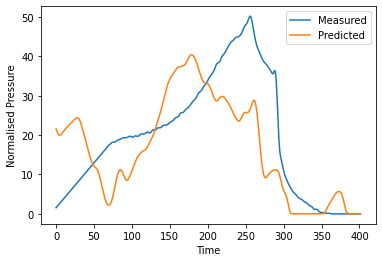

--------------------------------
Predicting Bladder Pressure for dataset 20504 6
24/24 [==============================] - 2s 87ms/step - loss: 8.6196 - mean_squared_error: 150.2153
Test loss: 8.61955451965332
Test accuracy: 150.21531677246094
Final score (MSE): 150.21532084966915
Final score (RMSE): 12.256235998448673
Final score (RMSPE): 649906.4045046123%
--------------------------------


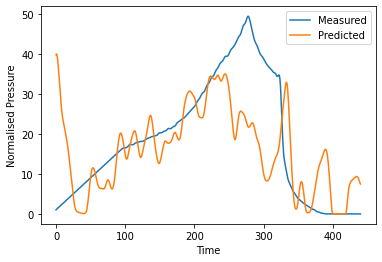

--------------------------------
Predicting Bladder Pressure for dataset 20504 7
25/25 [==============================] - 2s 87ms/step - loss: 11.4255 - mean_squared_error: 217.6848
Test loss: 11.425527572631836
Test accuracy: 217.684814453125
Final score (MSE): 217.68482138960408
Final score (RMSE): 14.75414590512118
Final score (RMSPE): 19447449.446329255%
--------------------------------


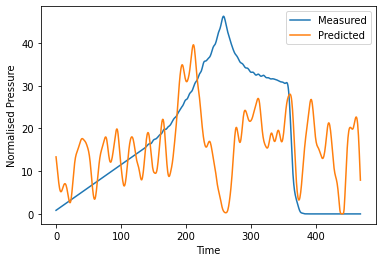

--------------------------------
Predicting Bladder Pressure for dataset 12784 1
23/23 [==============================] - 2s 85ms/step - loss: 8.8448 - mean_squared_error: 133.6448
Test loss: 8.844846725463867
Test accuracy: 133.64480590820312
Final score (MSE): 133.64480195368918
Final score (RMSE): 11.560484503414603
Final score (RMSPE): 144.74827570758825%
--------------------------------


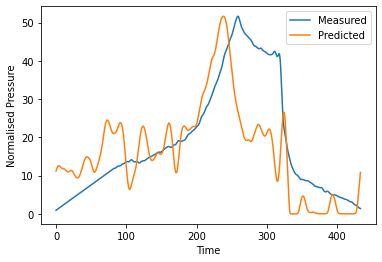

--------------------------------
Predicting Bladder Pressure for dataset 12784 2
22/22 [==============================] - 2s 83ms/step - loss: 9.3739 - mean_squared_error: 158.4804
Test loss: 9.373891830444336
Test accuracy: 158.48037719726562
Final score (MSE): 158.48038379165013
Final score (RMSE): 12.588899228751103
Final score (RMSPE): 94332.72319559925%
--------------------------------


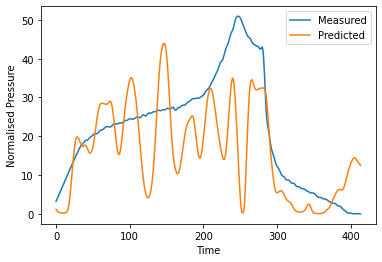

--------------------------------
Predicting Bladder Pressure for dataset 12784 3
22/22 [==============================] - 2s 78ms/step - loss: 8.1502 - mean_squared_error: 135.1583
Test loss: 8.150215148925781
Test accuracy: 135.15829467773438
Final score (MSE): 135.15829525677765
Final score (RMSE): 11.625759986202091
Final score (RMSPE): 82.34416388372031%
--------------------------------


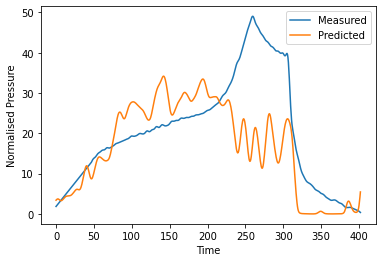

--------------------------------
Predicting Bladder Pressure for dataset 12784 4
23/23 [==============================] - 2s 82ms/step - loss: 10.4516 - mean_squared_error: 190.8644
Test loss: 10.451581954956055
Test accuracy: 190.8643798828125
Final score (MSE): 190.86439792100458
Final score (RMSE): 13.815368178988376
Final score (RMSPE): 83.3713080961813%
--------------------------------


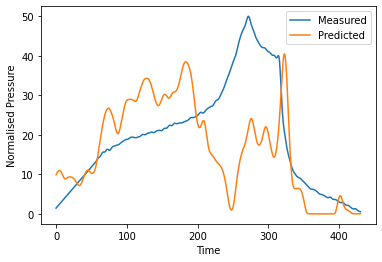

--------------------------------
Predicting Bladder Pressure for dataset 12784 5
23/23 [==============================] - 2s 82ms/step - loss: 7.6356 - mean_squared_error: 110.6705
Test loss: 7.635614395141602
Test accuracy: 110.6705322265625
Final score (MSE): 110.67053121828161
Final score (RMSE): 10.520006236608493
Final score (RMSPE): 4445.985429144023%
--------------------------------


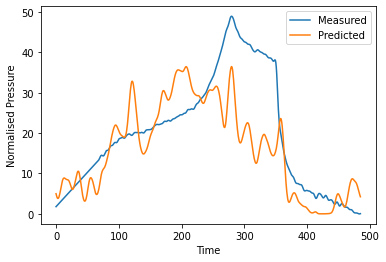

--------------------------------
Predicting Bladder Pressure for dataset 12784 6
24/24 [==============================] - 4s 84ms/step - loss: 9.5604 - mean_squared_error: 171.7571
Test loss: 9.560361862182617
Test accuracy: 171.75709533691406
Final score (MSE): 171.75711164894005
Final score (RMSE): 13.105613745603067
Final score (RMSPE): 3726.871802806869%
--------------------------------


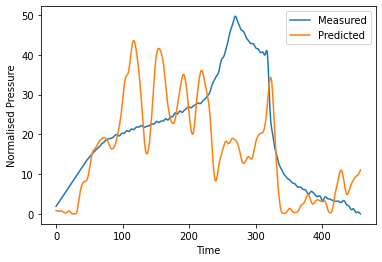

--------------------------------
Predicting Bladder Pressure for dataset 12784 7
26/26 [==============================] - 2s 79ms/step - loss: 12.4440 - mean_squared_error: 229.0063
Test loss: 12.443971633911133
Test accuracy: 229.00625610351562
Final score (MSE): 229.0062801635423
Final score (RMSE): 15.132953451443056
Final score (RMSPE): 743.1134689687016%
--------------------------------


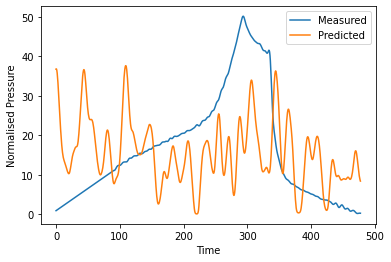

--------------------------------
Predicting Bladder Pressure for dataset 2625 1
19/19 [==============================] - 2s 83ms/step - loss: 3.3690 - mean_squared_error: 20.4463
Test loss: 3.368978261947632
Test accuracy: 20.446256637573242
Final score (MSE): 20.446252728656862
Final score (RMSE): 4.52175328038327
Final score (RMSPE): 43.655423813018636%
--------------------------------


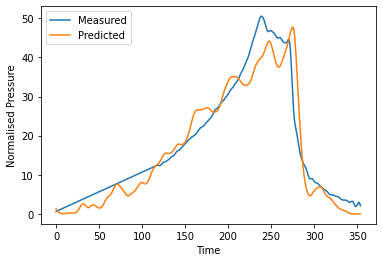

--------------------------------
Predicting Bladder Pressure for dataset 2625 2
19/19 [==============================] - 2s 87ms/step - loss: 4.9391 - mean_squared_error: 35.3306
Test loss: 4.939117431640625
Test accuracy: 35.33063888549805
Final score (MSE): 35.33064281788095
Final score (RMSE): 5.943958514145346
Final score (RMSPE): 49.657234360202686%
--------------------------------


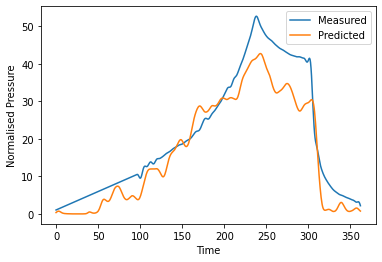

--------------------------------
Predicting Bladder Pressure for dataset 2625 3
24/24 [==============================] - 2s 86ms/step - loss: 3.4276 - mean_squared_error: 25.5761
Test loss: 3.4275686740875244
Test accuracy: 25.57606315612793
Final score (MSE): 25.576061686163914
Final score (RMSE): 5.057278090649546
Final score (RMSPE): 185970.21903271906%
--------------------------------


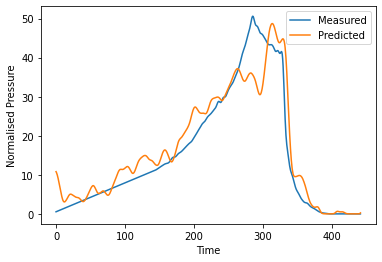

--------------------------------
Predicting Bladder Pressure for dataset 2625 4
24/24 [==============================] - 2s 84ms/step - loss: 8.8840 - mean_squared_error: 93.7545
Test loss: 8.884035110473633
Test accuracy: 93.75446319580078
Final score (MSE): 93.75446102499501
Final score (RMSE): 9.682688729118324
Final score (RMSPE): 64.70690346290748%
--------------------------------


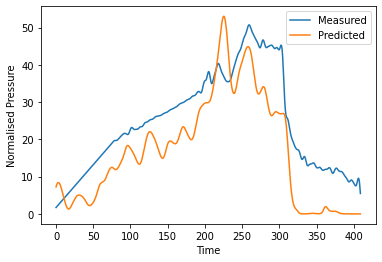

--------------------------------
Predicting Bladder Pressure for dataset 2625 5
19/19 [==============================] - 2s 82ms/step - loss: 8.3905 - mean_squared_error: 121.5904
Test loss: 8.39052677154541
Test accuracy: 121.5903549194336
Final score (MSE): 121.59035266173042
Final score (RMSE): 11.026801560821271
Final score (RMSPE): 4854.598116102707%
--------------------------------


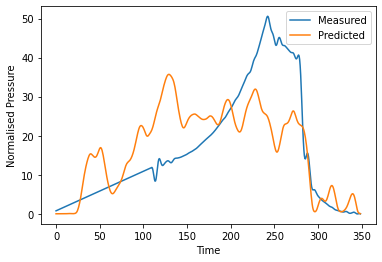

In [18]:
# Now test for all datasets
i=0
for name in names:
    print("--------------------------------")
    print("Predicting Bladder Pressure for dataset "+name)
    [scoreLSTM1, predictionsLSTM1] = nncLSTM.TestNN(inputTestLSTM[i], targetTestLSTM[i])
    print("Test loss:", scoreLSTM1[0])
    print("Test accuracy:", scoreLSTM1[1])

    targetTestLSTM1 = targetTestLSTM[i]
    filename = name+"_predictions2625.csv"
    np.savetxt(filename, predictionsLSTM1, delimiter=',')

    scoreLSTM1 = metrics.mean_squared_error(predictionsLSTM1.flatten(),targetTestLSTM1[:,0].flatten())
    print("Final score (MSE): {}".format(scoreLSTM1))

    scoreLSTM2 = np.sqrt(metrics.mean_squared_error(predictionsLSTM1.flatten(),targetTestLSTM1[:,0].flatten()))
    print("Final score (RMSE): {}".format(scoreLSTM2))

    rmspe = 100*np.sqrt(np.mean(np.square(((targetTestLSTM1[:,0].flatten() - predictionsLSTM1.flatten()) / targetTestLSTM1[:,0].flatten())), axis=0))
    print("Final score (RMSPE): {}%".format(rmspe))
    print("--------------------------------")

    nn.PlotRegression(predictionsLSTM1[:,0].flatten(), targetTestLSTM1[:,0].flatten(), tData[i], sort=False)
    
    i=i+1